# Cell 0: Install necessary packages

In [1]:
!pip install --quiet diffusers transformers accelerate torch pillow pandas numpy

# Cell 1: Imports and installs

In [2]:
import os
import io
import base64
import time
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import numpy as np
import torch
from PIL import Image
from IPython.display import display, HTML
from diffusers import StableDiffusionPipeline

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Environment ready. Using Stable Diffusion v1.5. Results saved to:", RESULTS_DIR.resolve())

Environment ready. Using Stable Diffusion v1.5. Results saved to: /content/results


# Cell 2: Configuration [EDIT FOR CUSTOMIZATION!]

In [14]:
# Number of realistic and unrealistic images to generate
x_realistic = 5
y_unrealistic = 2

# Edit this list to include the textual concepts you want to compare images against.
text_prompts = [
    "a photo of a dog",
    "an image of a cat",
    "a fluffy golden retriever running in a park",
    "a siamese cat sleeping on a couch",
    "a red sports car on a highway",
    "a portrait of a bald man in studio lighting",
    "an aerial view of a city at night",
    "a close-up of a sunflower",
    "a painting of a landscape with mountains",
    "a fantasy castle on a cliff"
]

# Realistic image generation prompts (x entries)
realistic_prompts = [
    "a high-resolution photo of a fluffy golden retriever",
    "a realistic photograph of a tabby cat sleeping",
    "a close-up photo of a dog running with tongue out",
    "a realistic portrait photo of a siamese cat",
    "a photo of a small brown dog sitting on a wooden floor"
    "a cartoon-style dragon breathing fire",
    "a futuristic city with flying cars at sunset",
    "a realistic photo of a pepperoni pizza on a wooden table"
    "a high-resolution photo of a fluffy golden retriever",
    "a realistic photograph of a tabby cat sleeping",
    "a close-up photo of a dog running with tongue out",
    "a realistic portrait photo of a siamese cat",
    "a photo of a small brown dog sitting on a wooden floor"

][:x_realistic]

# Unrealistic prompts (y entries)

unrealistic_prompts = [
    "a centaur raiding an alien outpost on Mars, cinematic scene",
    "a giant astronaut-octopus playing a piano on the Moon"
    "a dragon made of water flying over a city made of glass",
    "a two-headed cat playing chess in zero gravity"
][:y_unrealistic]

print("Configuration ready. Realistic prompts:", len(realistic_prompts), "Unrealistic prompts:", len(unrealistic_prompts))




Configuration ready. Realistic prompts: 5 Unrealistic prompts: 2


# Cell 3: Initialize Stable Diffusion + CLIP model/processor

In [15]:
from diffusers import StableDiffusionPipeline
from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    safety_checker=None,
    feature_extractor=None,
    torch_dtype=torch.float16
).to(device)

print("Stable Diffusion initialized (safety checker disabled).")

clip_model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(clip_model_name)
model = CLIPModel.from_pretrained(clip_model_name).to(device)
model.eval()

def normalize_embeddings(tensor: torch.Tensor) -> torch.Tensor:
    return tensor / tensor.norm(p=2, dim=-1, keepdim=True)

def compute_text_embeddings(texts):
    with torch.no_grad():
        inputs = processor(text=texts, images=None, return_tensors="pt", padding=True).to(device)
        text_emb = model.get_text_features(**inputs)
        text_emb = normalize_embeddings(text_emb)
    return text_emb.cpu().numpy()

def compute_image_embeddings(images):
    with torch.no_grad():
        inputs = processor(images=images, return_tensors="pt").to(device)
        img_emb = model.get_image_features(**inputs)
        img_emb = normalize_embeddings(img_emb)
    return img_emb.cpu().numpy()

print("Stable Diffusion and CLIP initialized.")

Using device: cuda


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Stable Diffusion initialized (safety checker disabled).
Stable Diffusion and CLIP initialized.


# Cell 4: Stable Diffusion image generator

In [16]:
# Generates and saves an image

def generate_and_save(prompt: str, idx: int, kind: str = "realistic"):
    print(f"Generating SD image for [{kind} #{idx}]: {prompt}")

    result = pipe(prompt, num_inference_steps=28, guidance_scale=7.5)
    img = result.images[0]

    out_path = RESULTS_DIR / f"{kind}_{idx}_cand_0.png"
    img.save(out_path)

    return out_path, [out_path]

def generate_batch(prompts: List[str], kind: str):
    pil_images = []
    representative_paths = []
    all_candidate_paths = []

    for i, p in enumerate(prompts):
        rep_path, cand_paths = generate_and_save(p, i, kind)
        representative_paths.append(rep_path)
        all_candidate_paths.append(cand_paths)
        pil_images.append(Image.open(rep_path).convert("RGB"))

    return pil_images, representative_paths, all_candidate_paths

# Cell 5: Generate images

In [17]:
print("Starting generation of realistic images...")
real_images_pil, real_repr_paths, real_all_paths = generate_batch(realistic_prompts, kind="realistic")
print("Realistic generation done.\n")

print("Starting generation of unrealistic images...")
unreal_images_pil, unreal_repr_paths, unreal_all_paths = generate_batch(unrealistic_prompts, kind="unrealistic")
print("Unrealistic generation done.\n")

all_images_pil = real_images_pil + unreal_images_pil
all_prompts_used = realistic_prompts + unrealistic_prompts
all_repr_paths = real_repr_paths + unreal_repr_paths
all_candidate_paths = real_all_paths + unreal_all_paths

print(f"Total images generated (representatives): {len(all_images_pil)}")

Starting generation of realistic images...
Generating SD image for [realistic #0]: a high-resolution photo of a fluffy golden retriever


  0%|          | 0/28 [00:00<?, ?it/s]

Generating SD image for [realistic #1]: a realistic photograph of a tabby cat sleeping


  0%|          | 0/28 [00:00<?, ?it/s]

Generating SD image for [realistic #2]: a close-up photo of a dog running with tongue out


...

Realistic generation done.

Starting generation of unrealistic images...
Generating SD image for [unrealistic #0]: a centaur raiding an alien outpost on Mars, cinematic scene


  0%|          | 0/28 [00:00<?, ?it/s]

Generating SD image for [unrealistic #1]: a giant astronaut-octopus playing a piano on the Moona dragon made of water flying over a city made of glass


  0%|          | 0/28 [00:00<?, ?it/s]

Unrealistic generation done.

Total images generated (representatives): 7


In [22]:
# analysis: deeper look at CLIP top-1 similarities

import numpy as np
import pandas as pd

# Make sure top1_score is numeric
df["top1_score"] = df["top1_score"].astype(float)

real_mask = df["is_realistic"]
unreal_mask = ~df["is_realistic"]

real_scores = df.loc[real_mask, "top1_score"]
unreal_scores = df.loc[unreal_mask, "top1_score"]

print("=== Top-1 similarity stats ===\n")

print("Realistic images:")
print(f"  count : {real_scores.count()}")
print(f"  mean  : {real_scores.mean():.4f}")
print(f"  std   : {real_scores.std(ddof=1):.4f}")
print(f"  min   : {real_scores.min():.4f}")
print(f"  25%   : {real_scores.quantile(0.25):.4f}")
print(f"  50%   : {real_scores.median():.4f}")
print(f"  75%   : {real_scores.quantile(0.75):.4f}")
print(f"  max   : {real_scores.max():.4f}\n")

print("Unrealistic images:")
print(f"  count : {unreal_scores.count()}")
print(f"  mean  : {unreal_scores.mean():.4f}")
print(f"  std   : {unreal_scores.std(ddof=1):.4f}")
print(f"  min   : {unreal_scores.min():.4f}")
print(f"  25%   : {unreal_scores.quantile(0.25):.4f}")
print(f"  50%   : {unreal_scores.median():.4f}")
print(f"  75%   : {unreal_scores.quantile(0.75):.4f}")
print(f"  max   : {unreal_scores.max():.4f}\n")

# Difference in means + rough effect size
mean_diff = real_scores.mean() - unreal_scores.mean()
pooled_var = (real_scores.var(ddof=1) + unreal_scores.var(ddof=1)) / 2
pooled_std = float(np.sqrt(pooled_var)) if pooled_var > 0 else np.nan
cohen_d = mean_diff / pooled_std if pooled_std > 0 else np.nan

print("=== Comparison ===")
print(f"Mean difference (real - unreal): {mean_diff:.4f}")
print(f"Approx. effect size (Cohen's d): {cohen_d:.3f}\n")

# Which text prompts show up most often as top-1 for each group
print("=== Most common top-1 text matches (realistic images) ===")
print(df.loc[real_mask, "top1_text"].value_counts().head(10), "\n")

print("=== Most common top-1 text matches (unrealistic images) ===")
print(df.loc[unreal_mask, "top1_text"].value_counts().head(10))


=== Top-1 similarity stats ===

Realistic images:
  count : 5
  mean  : 0.2852
  std   : 0.0111
  min   : 0.2738
  25%   : 0.2753
  50%   : 0.2837
  75%   : 0.2959
  max   : 0.2972

Unrealistic images:
  count : 2
  mean  : 0.2110
  std   : 0.0447
  min   : 0.1794
  25%   : 0.1952
  50%   : 0.2110
  75%   : 0.2268
  max   : 0.2426

=== Comparison ===
Mean difference (real - unreal): 0.0742
Approx. effect size (Cohen's d): 2.279

=== Most common top-1 text matches (realistic images) ===
top1_text
an image of a cat                              2
a photo of a dog                               2
a fluffy golden retriever running in a park    1
Name: count, dtype: int64 

=== Most common top-1 text matches (unrealistic images) ===
top1_text
an image of a cat    2
Name: count, dtype: int64


# Cell 6: Compute embeddings

In [23]:
print("Computing text embeddings for text_prompts (embedding bank)...")
text_embeddings = compute_text_embeddings(text_prompts)
print("Text embeddings shape:", text_embeddings.shape)

print("Computing image embeddings for generated images...")
image_embeddings = compute_image_embeddings(all_images_pil)
print("Image embeddings shape:", image_embeddings.shape)

Computing text embeddings for text_prompts (embedding bank)...
Text embeddings shape: (10, 512)
Computing image embeddings for generated images...
Image embeddings shape: (7, 512)


# Cell 7: Similarity computation (cosine similarity) and results table

In [25]:
def cosine_similarity_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    # Note they are pre-normalized so we ignore that and just do dot prod.
    return np.dot(A, B.T)

# Compute similarities: images x texts
sims = cosine_similarity_matrix(image_embeddings, text_embeddings)

# For each image, find top-k matching text entries and report scores
top_k = 3
rows = []
for i, img_path in enumerate(all_repr_paths):
    sim_row = sims[i]
    top_idx = np.argsort(-sim_row)[:top_k]
    top_texts = [text_prompts[j] for j in top_idx]
    top_scores = [float(sim_row[j]) for j in top_idx]

    row = {
        "image_index": i,
        "image_path": str(img_path),
        "image_prompt_used": all_prompts_used[i],
        "top1_text": top_texts[0],
        "top1_score": top_scores[0],
        "top2_text": top_texts[1] if len(top_texts) > 1 else "",
        "top2_score": top_scores[1] if len(top_scores) > 1 else None,
        "top3_text": top_texts[2] if len(top_texts) > 2 else "",
        "top3_score": top_scores[2] if len(top_scores) > 2 else None,
        "is_realistic": i < len(real_images_pil)
    }
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = RESULTS_DIR / "similarity_results.csv"
df.to_csv(csv_path, index=False)
print("Similarity results saved to:", csv_path)

np.save(RESULTS_DIR / "similarity_matrix.npy", sims)

Similarity results saved to: results/similarity_results.csv


# Cell 8: Show summary statistics comparing realistic vs unrealistic

In [26]:
real_count = len(real_images_pil)
unreal_count = len(unreal_images_pil)

# Average top1 similarity for realistic vs unrealistic
top1_scores = df["top1_score"].astype(float)
avg_real_top1 = top1_scores[df["is_realistic"]].mean()
avg_unreal_top1 = top1_scores[~df["is_realistic"]].mean()

summary_text = f"""
Summary:
- realistic images (n={real_count}) average top-1 similarity to text bank = {avg_real_top1:.4f}
- unrealistic images (n={unreal_count}) average top-1 similarity to text bank = {avg_unreal_top1:.4f}
Saved CSV: {csv_path}
"""

print(summary_text)


Summary:
- realistic images (n=5) average top-1 similarity to text bank = 0.2852
- unrealistic images (n=2) average top-1 similarity to text bank = 0.2110
Saved CSV: results/similarity_results.csv



# Cell 9: Display images with their top matches

Image #0 | generated prompt: a high-resolution photo of a fluffy golden retriever | top1: [a fluffy golden retriever running in a park] (0.2972)


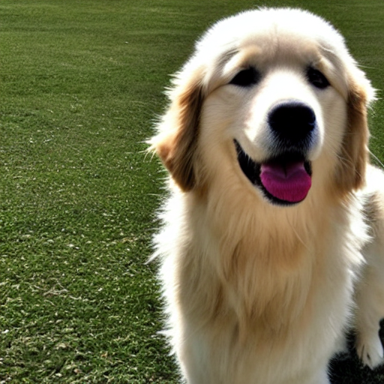

Top 3 matches:
  1) a fluffy golden retriever running in a park (0.2972)
  2) a photo of a dog (0.2708)
  3) an image of a cat (0.2002)


Image #1 | generated prompt: a realistic photograph of a tabby cat sleeping | top1: [an image of a cat] (0.2753)


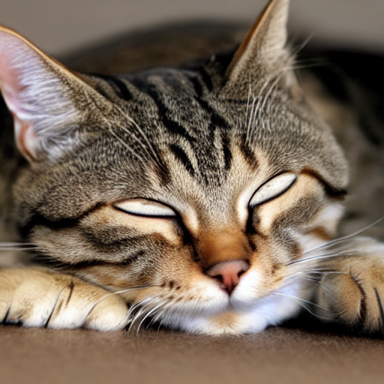

Top 3 matches:
  1) an image of a cat (0.2753)
  2) a siamese cat sleeping on a couch (0.2537)
  3) a photo of a dog (0.2159)


Image #2 | generated prompt: a close-up photo of a dog running with tongue out | top1: [a photo of a dog] (0.2738)


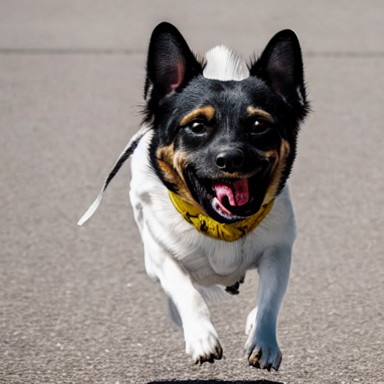

Top 3 matches:
  1) a photo of a dog (0.2738)
  2) an image of a cat (0.2213)
  3) a fluffy golden retriever running in a park (0.2055)


Image #3 | generated prompt: a realistic portrait photo of a siamese cat | top1: [an image of a cat] (0.2959)


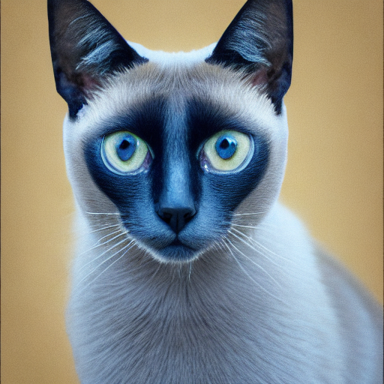

Top 3 matches:
  1) an image of a cat (0.2959)
  2) a siamese cat sleeping on a couch (0.2665)
  3) a photo of a dog (0.2384)


Image #4 | generated prompt: a photo of a small brown dog sitting on a wooden floora cartoon-style dragon breathing fire | top1: [a photo of a dog] (0.2837)


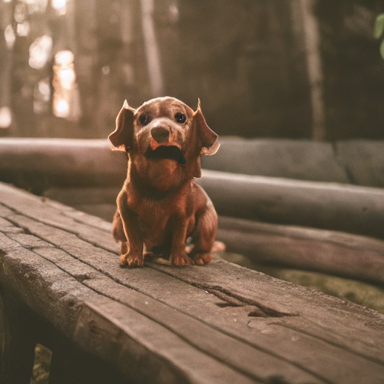

Top 3 matches:
  1) a photo of a dog (0.2837)
  2) an image of a cat (0.2387)
  3) a fluffy golden retriever running in a park (0.2226)


Image #5 | generated prompt: a centaur raiding an alien outpost on Mars, cinematic scene | top1: [an image of a cat] (0.2426)


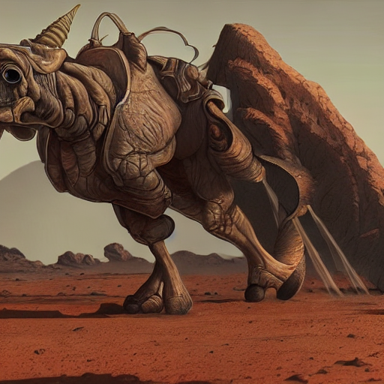

Top 3 matches:
  1) an image of a cat (0.2426)
  2) a photo of a dog (0.2284)
  3) a painting of a landscape with mountains (0.1825)


Image #6 | generated prompt: a giant astronaut-octopus playing a piano on the Moona dragon made of water flying over a city made of glass | top1: [an image of a cat] (0.1794)


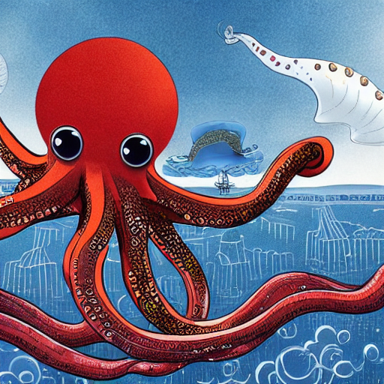

Top 3 matches:
  1) an image of a cat (0.1794)
  2) a photo of a dog (0.1776)
  3) a portrait of a bald man in studio lighting (0.1614)


Full similarity results table (saved to CSV):


image_index,image_path,image_prompt_used,top1_text,top1_score,top2_text,top2_score,top3_text,top3_score,is_realistic
0,results/realistic_0_cand_0.png,a high-resolution photo of a fluffy golden retriever,a fluffy golden retriever running in a park,0.297205,a photo of a dog,0.270780,an image of a cat,0.200174,True
1,results/realistic_1_cand_0.png,a realistic photograph of a tabby cat sleeping,an image of a cat,0.275257,a siamese cat sleeping on a couch,0.253729,a photo of a dog,0.215882,True
2,results/realistic_2_cand_0.png,a close-up photo of a dog running with tongue out,a photo of a dog,0.273846,an image of a cat,0.221329,a fluffy golden retriever running in a park,0.205537,True
3,results/realistic_3_cand_0.png,a realistic portrait photo of a siamese cat,an image of a cat,0.295940,a siamese cat sleeping on a couch,0.266460,a photo of a dog,0.238450,True
4,results/realistic_4_cand_0.png,a photo of a small brown dog sitting on a wooden floora cartoon-style dragon breathing fire,a photo of a dog,0.283718,an image of a cat,0.238670,a fluffy golden retriever running in a park,0.222621,True
5,results/unrealistic_0_cand_0.png,"a centaur raiding an alien outpost on Mars, cinematic scene",an image of a cat,0.242593,a photo of a dog,0.228419,a painting of a landscape with mountains,0.182514,False
6,results/unrealistic_1_cand_0.png,a giant astronaut-octopus playing a piano on the Moona dragon made of water flying over a city made of glass,an image of a cat,0.179357,a photo of a dog,0.177595,a portrait of a bald man in studio lighting,0.161381,False


In [27]:
from IPython.display import Image as IPyImage, display_markdown

def display_results_table(df: pd.DataFrame):\
    display(HTML(df.to_html(index=False)))

# Show each images top 3 text descriptions
for idx, row in df.iterrows():
    img_p = row["image_path"]
    caption = f"Image #{row['image_index']} | generated prompt: {row['image_prompt_used']} | top1: [{row['top1_text']}] ({row['top1_score']:.4f})"
    print("="*80)
    print(caption)

    display(Image.open(img_p).resize((384, 384)))

    print("Top 3 matches:")
    print("  1)", row["top1_text"], f"({row['top1_score']:.4f})")
    print("  2)", row["top2_text"], f"({row['top2_score']:.4f})")
    print("  3)", row["top3_text"], f"({row['top3_score']:.4f})")
    print("\n")

print("Full similarity results table (saved to CSV):")
display_results_table(df)

# Cell 10: Save a report summarizing results

In [28]:
report_md = f"# Linking Images and Text - Results\n\n"
report_md += f"Generated {len(all_images_pil)} representative images: {len(real_images_pil)} realistic, {len(unreal_images_pil)} unrealistic.\n\n"
report_md += "## Average top-1 similarities\n\n"
report_md += f"- realistic images average top1: **{avg_real_top1:.4f}**\n"
report_md += f"- unrealistic images average top1: **{avg_unreal_top1:.4f}**\n\n"
report_md += "## Files\n\n"

for p in sorted(RESULTS_DIR.glob("*")):
    report_md += f"- {p.name}\n"

(report_path := RESULTS_DIR / "REPORT.md").write_text(report_md)
print("Report written to:", report_path)
print("\nDone. You can download the 'results/' directory or push it to GitHub. The CSV and images are standard files and should be visible on GitHub when uploaded.")

Report written to: results/REPORT.md

Done. You can download the 'results/' directory or push it to GitHub. The CSV and images are standard files and should be visible on GitHub when uploaded.


In [29]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [30]:
import os
import shutil

# Where your results are currently
src_results = "/content/results"

# Where in Drive you want to save them
# This will create: MyDrive/AI_Projects/LinkingImgsAndTxt/results_run1
drive_root = "/content/drive/MyDrive"
project_folder = os.path.join(drive_root, "AI_Projects", "LinkingImgsAndTxt")
save_folder = os.path.join(project_folder, "results_run1")

# Make sure the parent folder exists
os.makedirs(project_folder, exist_ok=True)

# Copy the entire results/ directory into Drive
shutil.copytree(src_results, save_folder, dirs_exist_ok=True)

print(f"Copied results to: {save_folder}")


Copied results to: /content/drive/MyDrive/AI_Projects/LinkingImgsAndTxt/results_run1
